In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, TimeDistributed, Bidirectional
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.metrics import categorical_accuracy
from tensorflow.keras import backend as K
from core.data import load_from_kaggle


c:\Users\yamen\Desktop\Weiterbildung\visual Studio Code\mein-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "alfrandom/protein-secondary-structure" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\protein-secondary-structure' already exists with files. Skipping download (replace=False).


In [3]:
files

['2018-06-06-pdb-intersect-pisces.csv', '2018-06-06-ss.cleaned.csv']

In [4]:
df = pd.read_csv('../data/raw/protein-secondary-structure/2018-06-06-ss.cleaned.csv')
df.head()

,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa
0,1A30,C,EDL,CBC,CEC,3,False
1,1B05,B,KCK,CBC,CEC,3,False
2,1B0H,B,KAK,CBC,CEC,3,False
3,1B1H,B,KFK,CBC,CEC,3,False
4,1B2H,B,KAK,CBC,CEC,3,False


In [5]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(393732, 7)

'Description'

,count,mean,std,min,25%,50%,75%,max
len,393732.0,260.21,196.86,3.0,131.0,223.0,336.0,5037.0


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
pdb_id,object,0,139496,"[5M2P, 1SZK, 1PVH]"
chain_code,object,0,62,"[u, D, B]"
seq,object,0,95915,[GPLGSMSIQKVHAREILDSRGNPTIEVEITTGKGMFRSCVPSGAS...
sst8,object,0,329636,[CCCCCCCCCCCSHHHHHHTTTTCCTTCSSCHHHHHHTTEEECSST...
sst3,object,0,289917,[CCCEEEEEEEECCCHHHHHCCHHHCCCCCCCCEEEEEEEEECCCC...
len,int64,0,1366,"[126, 219, 117]"
has_nonstd_aa,bool,0,2,"[False, False, False]"


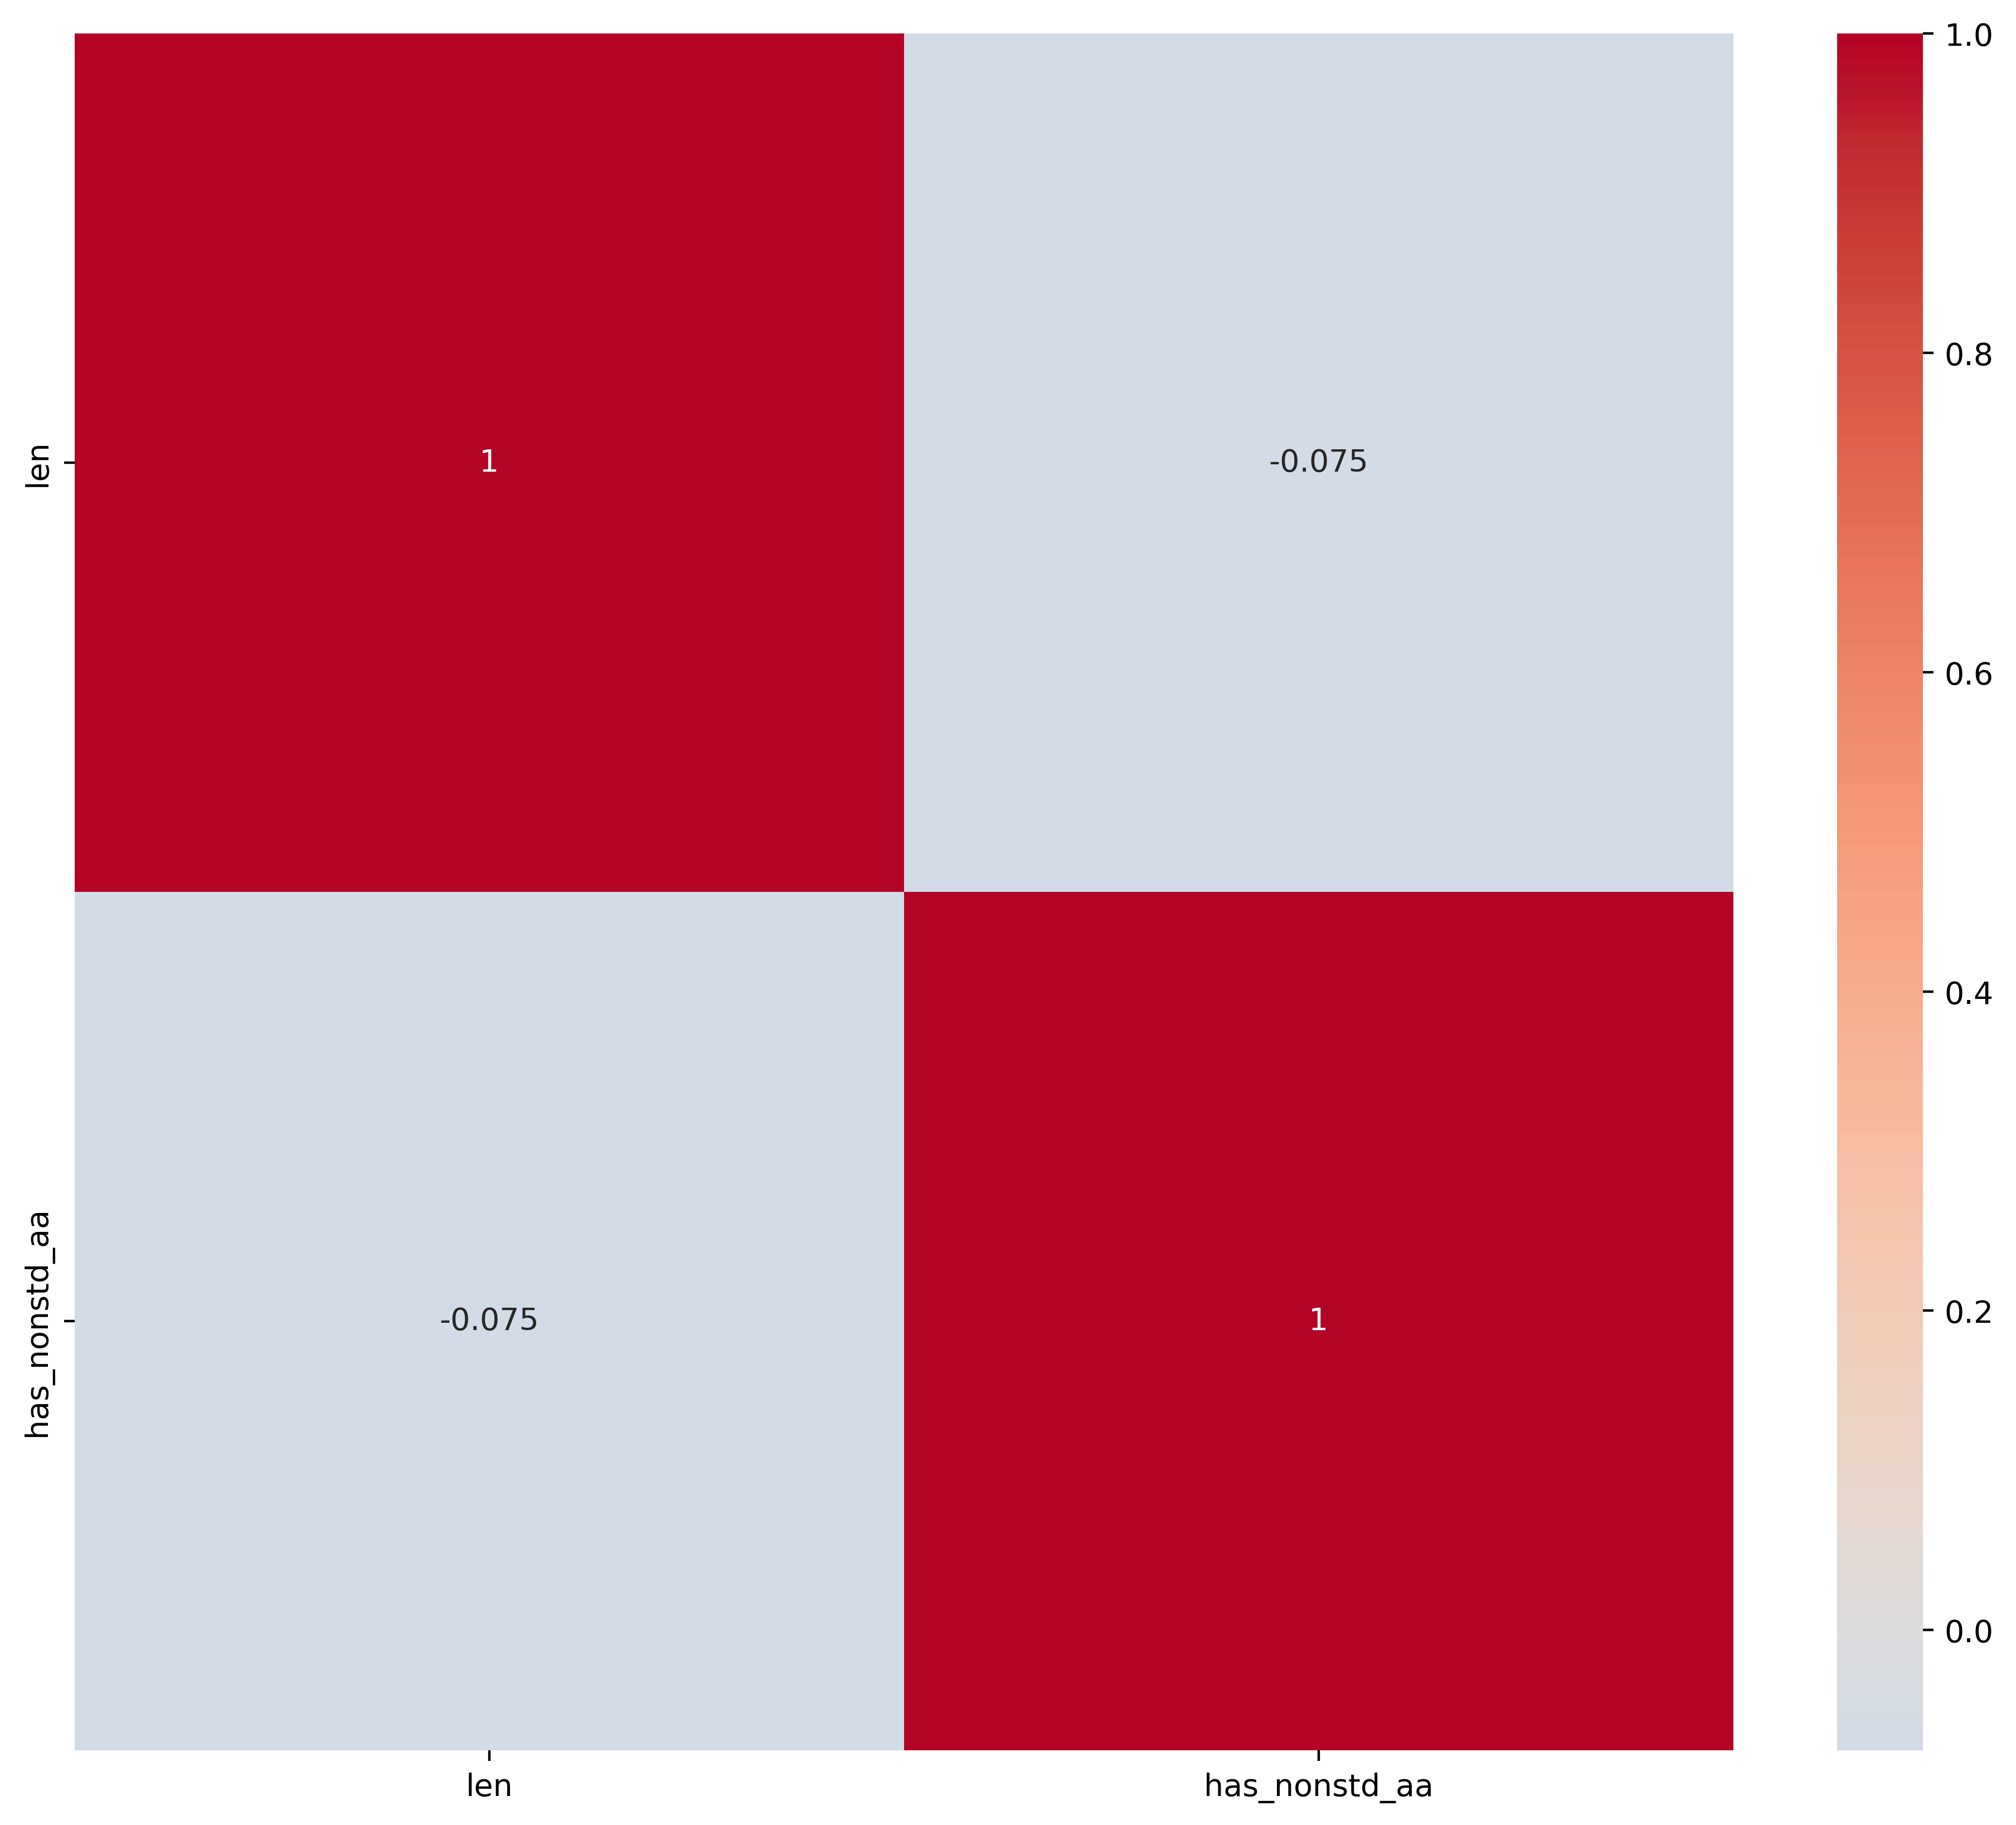

In [6]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=400)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);

In [7]:
#the length where 50% of sequences are shorter
np.percentile(df.len, 50)

np.float64(223.0)

Most common length: 231
plot distribution of protein sequence length


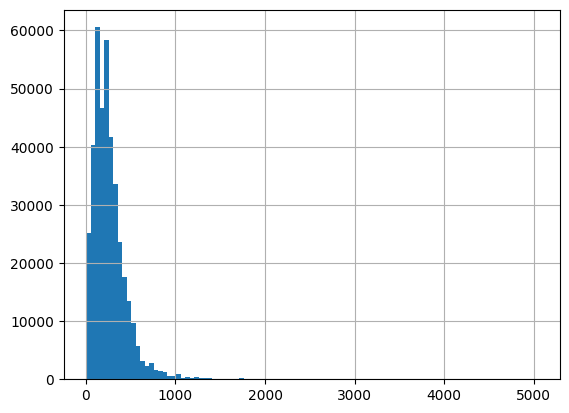

In [50]:
#plot distribution of protein length
df.len.hist(bins=100)
most_common_length = df.len.value_counts().idxmax()
print("Most common length:", most_common_length)
print('plot distribution of protein sequence length')


In [9]:
#selection of specific data
maxlen_seq = 128
input_seqs = df['seq'][(df.len <= maxlen_seq) & (~df.has_nonstd_aa)].values
target_seqs = df['sst3'][(df.len <= maxlen_seq) & (~df.has_nonstd_aa)].values
#Convert sequences into n-grams
def seq2ngrams(seqs, n=3):
    return [[seq[i:i+n] for i in range(len(seq))] for seq in seqs]

input_grams = seq2ngrams(input_seqs)
display(input_grams[0])


['EDL', 'DL', 'L']

In [10]:
#tokenization (convert text → numbers)
tokenizer_encoder = Tokenizer()
tokenizer_encoder.fit_on_texts(input_grams)
input_data = tokenizer_encoder.texts_to_sequences(input_grams)
#padding
input_data = sequence.pad_sequences(input_data, maxlen=maxlen_seq, padding='post')
print(input_data[:10])

[[ 568 7009   24 ...    0    0    0]
 [3358 7562    2 ...    0    0    0]
 [  36 2671    2 ...    0    0    0]
 ...
 [ 883 4668    2 ...    0    0    0]
 [  36 2671    2 ...    0    0    0]
 [ 446 4618    2 ...    0    0    0]]


In [11]:
#Target encoding
tokenizer_decoder = Tokenizer(char_level=True)
tokenizer_decoder.fit_on_texts(target_seqs)
target_data = tokenizer_decoder.texts_to_sequences(target_seqs)
target_data = sequence.pad_sequences(target_data, maxlen=maxlen_seq, padding='post')
target_data = to_categorical(target_data)
target_data[:3]

array([[[0., 1., 0., 0.],
        [0., 0., 0., 1.],
        [0., 1., 0., 0.],
        ...,
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]],

       [[0., 1., 0., 0.],
        [0., 0., 0., 1.],
        [0., 1., 0., 0.],
        ...,
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]],

       [[0., 1., 0., 0.],
        [0., 0., 0., 1.],
        [0., 1., 0., 0.],
        ...,
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]]], shape=(3, 128, 4))

In [12]:
n_words = len(tokenizer_encoder.word_index) + 1
n_tags = len(tokenizer_decoder.word_index) + 1
print(n_words, n_tags)

8421 4


In [40]:
reverse_index = {v: k for k, v in tokenizer_encoder.word_index.items()}

print(reverse_index[12])
print(reverse_index[45])
print(reverse_index[98])

f
ftpte
grnll


In [13]:
#data structure
input_data.shape, target_data.shape

((88751, 128), (88751, 128, 4))

In [14]:
#Build the model
input = Input(shape=(maxlen_seq,))

In [15]:
#Embedding layer
x = Embedding(input_dim=n_words, output_dim=128)(input)

In [16]:
#Bidirectional LSTM
x = Bidirectional(LSTM(units=64, return_sequences=True, recurrent_dropout=0.1))(x)

In [17]:
#Output layer
y = TimeDistributed(Dense(n_tags, activation="softmax"))(x)
model = Model(input, y)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 128, 128)       │     1,077,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 128, 4)         │           516 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,177,220 (4.49 MB)

 Trainable params: 1,177,220 (4.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#exclude padding 0 for realistic accuracy
def q3_acc(y_true, y_pred):
    y = tf.argmax(y_true, axis=-1)
    y_ = tf.argmax(y_pred, axis=-1)
    mask = tf.greater(y, 0)
    return K.cast(K.equal(tf.boolean_mask(y, mask), tf.boolean_mask(y_, mask)), K.floatx())


In [19]:
#training of medel
model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy", q3_acc])

X_train, X_test, y_train, y_test = train_test_split(input_data, target_data, test_size=.4, random_state=0)
seq_train, seq_test, target_train, target_test = train_test_split(input_seqs, target_seqs, test_size=.4, random_state=0)

model.fit(X_train, y_train, batch_size=128, epochs=5, validation_data=(X_test, y_test), verbose=1)


Epoch 1/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 382s 873ms/step - accuracy: 0.7036 - loss: 0.6029 - q3_acc: 0.5290 - val_accuracy: 0.8070 - val_loss: 0.4536 - val_q3_acc: 0.6940
Epoch 2/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 406s 974ms/step - accuracy: 0.8426 - loss: 0.3785 - q3_acc: 0.7491 - val_accuracy: 0.8566 - val_loss: 0.3513 - val_q3_acc: 0.7727
Epoch 3/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 399s 957ms/step - accuracy: 0.8695 - loss: 0.3248 - q3_acc: 0.7919 - val_accuracy: 0.8725 - val_loss: 0.3170 - val_q3_acc: 0.7979
Epoch 4/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 402s 965ms/step - accuracy: 0.8809 - loss: 0.2999 - q3_acc: 0.8101 - val_accuracy: 0.8737 - val_loss: 0.3177 - val_q3_acc: 0.7999
Epoch 5/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 434s 945ms/step - accuracy: 0.8890 - loss: 0.2813 - q3_acc: 0.8231 - val_accuracy: 0.8872 - val_loss: 0.2855 - val_q3_acc: 0.8212


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
training
---
Input: MGDKPIWEQIGSSFINHYYQLFDNDRTQLGAIYIDASCLTWEGQQFQGKAAIVEKLSSLPFQKIQHSITAQDHQPTPDSCIISMVVGQLKADEDPIMGFHQEFLLKNINDAWVCTNDMFRLALHNFG
Target: CCCCCHHHHHHHHHHHHHHHHHHHCHHHHHHHCCCCCEEEECCEEEECHHHHHHHHHHCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCCEEEEEEEEEEECCCCEEEEEEEEEEECCCCC
Result: CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHEEEEEEEEEEEEEEEHHHHHHHHHHCCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCCEEEEEEEEEEEECCEEEEEEEEEEECCCCCC


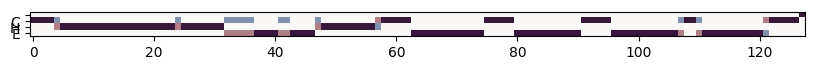

---
Input: SRGTQTE
Target: CEEEECC
Result: CCCCCCC


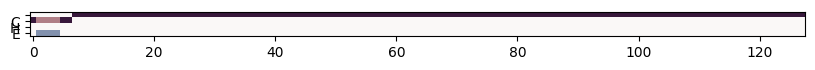

---
Input: MKEEKRSSTGFLVKQRAFLKLYMITMTEQERLYGLKLLKVLQSEFKEIGFKPNHTEVYRSLHELLDDGILKQIKVKKEGAKLQEVVLYQFKDYEAAKLYKKQLKVELDRCKKLIEKALSDNF
Target: CCCCCCCCCCCCCCHHHHHHHHHHHHHHCCCEECCCCHHHHHHHHCCCCCCCCHHHHHHHHHHHHHCCCEEEEECCCCCCCCCCCEEEEECCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC
Result: CCCCCCCCCCCCCCHHHHHHHHHHHHHHHCCCCHHHHHHHHHHHCCCCCCCCCHHHHHHHHHHHHHCCCEEEEEEECCCCCCEEEEEEECCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHCC


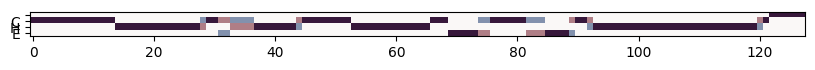

testing
---
Input: MKRQKRDRLERAHQRGYQAGIAGRSKEMCPYQTLNQRSQWLGGWREAMADRVVMAHHHHHH
Target: CCCCCHHHHHHHHHHHHHHHHCCCCCCCCCCCCHHHHHHHHHHHHHHHHHCCCCCCCCCCC
Result: CCCCCHHHHHHHHHHHHHHHHCCHCCCCCCCHHHHHHHHHHHHHHHHHHHHHCCCCCCCCC


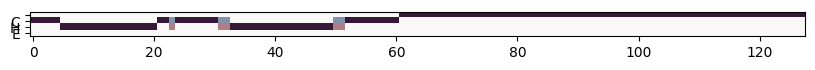

---
Input: YCQKWMWTCDEERKCCEGLVCRLWCKRIINM
Target: CCCCCCCECCCCCCCCCCCECCCECECCCCC
Result: CCCCCCCCCCCCCEEECCCCCCCEEEEEECC


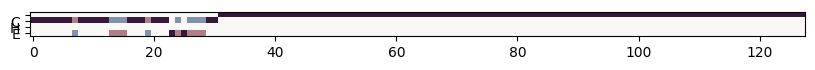

---
Input: TEFSEEQKRTLDLLFLFDRRMTEERRRWLSQRLGLNEEQIERWFRRKEQQI
Target: CCCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHCCCCCC
Result: CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCCCHHHHHHHHHCCCCC


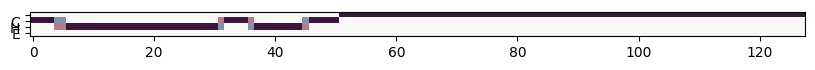

In [45]:
def onehot_to_seq(oh_seq, index):
    '''
    Convert a one-hot encoded sequence into a string of labels for secondary structure of proteins.

    Parameters
    ----------
    oh_seq : array-like, shape (seq_len, num_classes)
        One-hot encoded sequence or probability output from the model.
        Each row corresponds to a position in the sequence and contains
        class probabilities or one-hot values.

    index : dict
        Dictionary mapping class indices (int) to label characters (str),
        e.g. {1: 'C', 2: 'H', 3: 'E'}.

    Returns
    -------
    str
        Decoded sequence as a string of labels (e.g., "CCHHEE...").
        Stops decoding when a padding token (index 0) is encountered.'''
    
    s = ''
    for o in oh_seq:
        i = np.argmax(o)
        if i != 0:
            s += index[i]
        else:
            break
    return s

def plot_results(x, y, y_):
    y_ = np.eye(y_.shape[-1])[np.argmax(y_, axis=-1)]
    print("---")
    print("Input: " + str(x))
    print("Target: " + str(onehot_to_seq(y, revsere_decoder_index).upper()))
    print("Result: " + str(onehot_to_seq(y_, revsere_decoder_index).upper()))
    fig = plt.figure(figsize=(10,2))
    plt.imshow(y.T, cmap='Blues')
    plt.imshow(y_.T, cmap='Reds', alpha=.5)
    plt.yticks(range(4), [' '] + [revsere_decoder_index[i+1].upper() for i in range(3)])
    plt.show()
    
revsere_decoder_index = {value:key for key,value in tokenizer_decoder.word_index.items()}
revsere_encoder_index = {value:key for key,value in tokenizer_encoder.word_index.items()}

N=3
y_train_pred = model.predict(X_train[:N])
y_test_pred = model.predict(X_test[:N])
print('training')
for i in range(N):
    plot_results(seq_train[i], y_train[i], y_train_pred[i])
print('testing')
for i in range(N):
    plot_results(seq_test[i], y_test[i], y_test_pred[i])


Running for n=1
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
training
---
Input: MGDKPIWEQIGSSFINHYYQLFDNDRTQLGAIYIDASCLTWEGQQFQGKAAIVEKLSSLPFQKIQHSITAQDHQPTPDSCIISMVVGQLKADEDPIMGFHQEFLLKNINDAWVCTNDMFRLALHNFG
Target: CCCCCHHHHHHHHHHHHHHHHHHHCHHHHHHHCCCCCEEEECCEEEECHHHHHHHHHHCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCCEEEEEEEEEEECCCCEEEEEEEEEEECCCCC
Result: CCCCCCCECCCCCCCCHEEEECCCCCCHCCEEEECCCCCCCCCCCCCCHHHHHHHCCCCCHHHHHCCCCCCCCCCCCCCHEEEEECCCCCCCCCCCCCHHHHHHHHCCCCCEEECHHHHHHHHHCCC


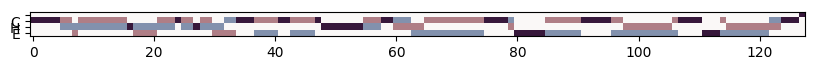

---
Input: SRGTQTE
Target: CEEEECC
Result: CCCCCCC


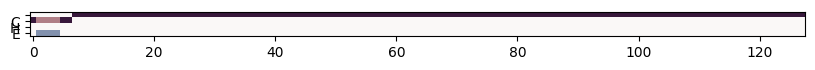

---
Input: MKEEKRSSTGFLVKQRAFLKLYMITMTEQERLYGLKLLKVLQSEFKEIGFKPNHTEVYRSLHELLDDGILKQIKVKKEGAKLQEVVLYQFKDYEAAKLYKKQLKVELDRCKKLIEKALSDNF
Target: CCCCCCCCCCCCCCHHHHHHHHHHHHHHCCCEECCCCHHHHHHHHCCCCCCCCHHHHHHHHHHHHHCCCEEEEECCCCCCCCCCCEEEEECCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC
Result: CCCCCCCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCCCCCCHHHHHHHHHCCCCHHHHHHCCCCCCHHHHHHHHHCHCHHHHHHHHHHHHHHHHHHHHHHHHCCCCCC


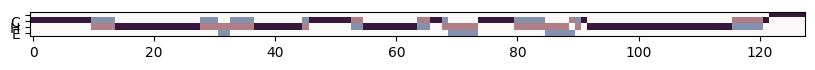

testing
---
Input: MKRQKRDRLERAHQRGYQAGIAGRSKEMCPYQTLNQRSQWLGGWREAMADRVVMAHHHHHH
Target: CCCCCHHHHHHHHHHHHHHHHCCCCCCCCCCCCHHHHHHHHHHHHHHHHHCCCCCCCCCCC
Result: CCCCCCCHHHHHHCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCHHHCCCCCCCCCCCCCC


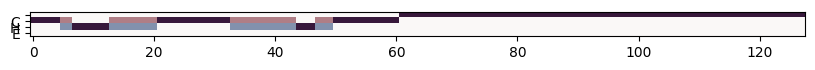

---
Input: YCQKWMWTCDEERKCCEGLVCRLWCKRIINM
Target: CCCCCCCECCCCCCCCCCCECCCECECCCCC
Result: CCCCCCCCCCHCCCCCHCCHHHEECCCCCCC


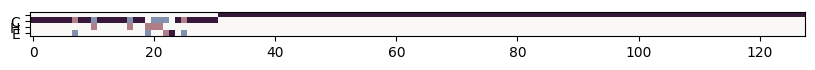

---
Input: TEFSEEQKRTLDLLFLFDRRMTEERRRWLSQRLGLNEEQIERWFRRKEQQI
Target: CCCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHCCCCCC
Result: CCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHCCCCCC


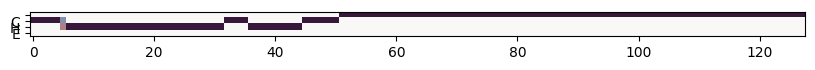


Running for n=3
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
training
---
Input: MGDKPIWEQIGSSFINHYYQLFDNDRTQLGAIYIDASCLTWEGQQFQGKAAIVEKLSSLPFQKIQHSITAQDHQPTPDSCIISMVVGQLKADEDPIMGFHQEFLLKNINDAWVCTNDMFRLALHNFG
Target: CCCCCHHHHHHHHHHHHHHHHHHHCHHHHHHHCCCCCEEEECCEEEECHHHHHHHHHHCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCCEEEEEEEEEEECCCCEEEEEEEEEEECCCCC
Result: CCCCCEEEHHCHHHHHHHHHHHCCCCHCCEEEEEEEEEEEEEEEEEEEEEEEEEEECCCCCCEEEEEEEEEEEEECCEEEEEEEEEEEEEEECCCEEEEEEEEEEECCCCEEEEEEEEEEEEECCEC


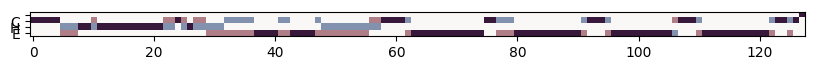

---
Input: SRGTQTE
Target: CEEEECC
Result: CCCCCCC


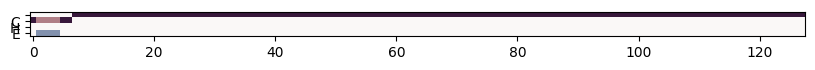

---
Input: MKEEKRSSTGFLVKQRAFLKLYMITMTEQERLYGLKLLKVLQSEFKEIGFKPNHTEVYRSLHELLDDGILKQIKVKKEGAKLQEVVLYQFKDYEAAKLYKKQLKVELDRCKKLIEKALSDNF
Target: CCCCCCCCCCCCCCHHHHHHHHHHHHHHCCCEECCCCHHHHHHHHCCCCCCCCHHHHHHHHHHHHHCCCEEEEECCCCCCCCCCCEEEEECCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC
Result: CCCCCCCCCCEEEEEEEHHHHHHEEHHHHHCCCCEEEEEEEECEEEEEEEEEEEEEEEEEEEEECCCCEEEEEEEECCCCEEEEEEEEEECCCCHHHHEEEEEEEEEHCHHEEHHHHHCCCC


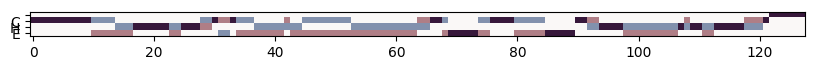

testing
---
Input: MKRQKRDRLERAHQRGYQAGIAGRSKEMCPYQTLNQRSQWLGGWREAMADRVVMAHHHHHH
Target: CCCCCHHHHHHHHHHHHHHHHCCCCCCCCCCCCHHHHHHHHHHHHHHHHHCCCCCCCCCCC
Result: CCCCCCCHHHHHHCCHHHHCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCCCCCCC


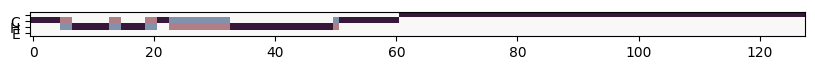

---
Input: YCQKWMWTCDEERKCCEGLVCRLWCKRIINM
Target: CCCCCCCECCCCCCCCCCCECCCECECCCCC
Result: CCCCCEECCCCCCEEECCCEEEEEEEEEEEC


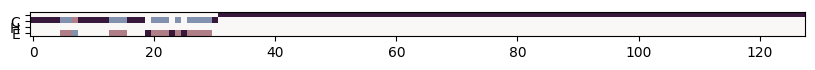

---
Input: TEFSEEQKRTLDLLFLFDRRMTEERRRWLSQRLGLNEEQIERWFRRKEQQI
Target: CCCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHCCCCCC
Result: CCCCCCCCCCHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHHHCCCC


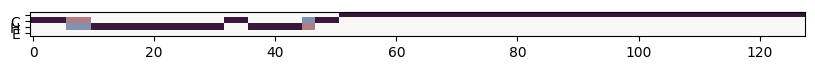


Running for n=5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
training
---
Input: MGDKPIWEQIGSSFINHYYQLFDNDRTQLGAIYIDASCLTWEGQQFQGKAAIVEKLSSLPFQKIQHSITAQDHQPTPDSCIISMVVGQLKADEDPIMGFHQEFLLKNINDAWVCTNDMFRLALHNFG
Target: CCCCCHHHHHHHHHHHHHHHHHHHCHHHHHHHCCCCCEEEECCEEEECHHHHHHHHHHCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCCEEEEEEEEEEECCCCEEEEEEEEEEECCCCC
Result: CCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHEEEEEEEEEECEEEEEHHHHHHHHHHCCCCCCEEEEEEEEEEEEECCCEEEEEEEEEEEECCCCEEEEEEEEEEEEECCEEEEEEEEEEECCCCCC


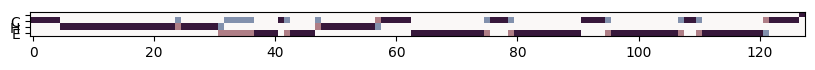

---
Input: SRGTQTE
Target: CEEEECC
Result: CCCCCCC


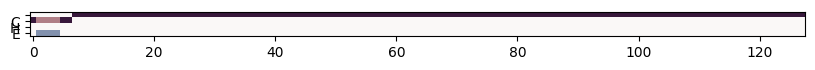

---
Input: MKEEKRSSTGFLVKQRAFLKLYMITMTEQERLYGLKLLKVLQSEFKEIGFKPNHTEVYRSLHELLDDGILKQIKVKKEGAKLQEVVLYQFKDYEAAKLYKKQLKVELDRCKKLIEKALSDNF
Target: CCCCCCCCCCCCCCHHHHHHHHHHHHHHCCCEECCCCHHHHHHHHCCCCCCCCHHHHHHHHHHHHHCCCEEEEECCCCCCCCCCCEEEEECCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC
Result: CCCCCCCCCCCCCHHHHHHHHHHHHHCCCCCCCCHHHHHHHHHHCCCCCCCCCHHHHHHHHHHHHCCCCEEEEEECCCCCCCEEEEEEEECHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCC


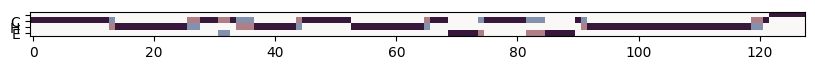

testing
---
Input: MKRQKRDRLERAHQRGYQAGIAGRSKEMCPYQTLNQRSQWLGGWREAMADRVVMAHHHHHH
Target: CCCCCHHHHHHHHHHHHHHHHCCCCCCCCCCCCHHHHHHHHHHHHHHHHHCCCCCCCCCCC
Result: CCCCHHHHHHHHHHHHHHHHCCCCCCCCCCCCHHHHHHHHHHHHHHHHCCCCCCCCCCCCC


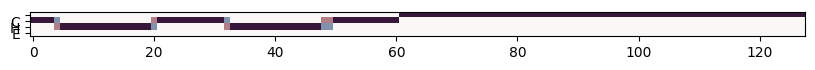

---
Input: YCQKWMWTCDEERKCCEGLVCRLWCKRIINM
Target: CCCCCCCECCCCCCCCCCCECCCECECCCCC
Result: CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC


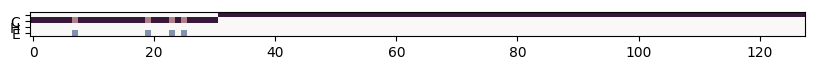

---
Input: TEFSEEQKRTLDLLFLFDRRMTEERRRWLSQRLGLNEEQIERWFRRKEQQI
Target: CCCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHCCCCCC
Result: CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCCCHHHHHHHHCCCCCC


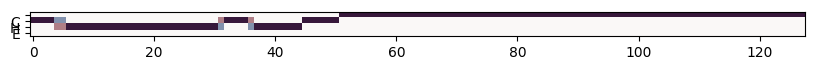

In [ ]:
#accuracy and Q3 accuracy for different n-grams
results = {}

for n in [1, 3, 5]:
    print(f"\nRunning for n={n}")
    
    # 1. Create n-grams
    input_grams = seq2ngrams(input_seqs, n)
    input_grams = [' '.join(seq) for seq in input_grams]
    
    # 2. Tokenizer
    tokenizer_encoder = Tokenizer()
    tokenizer_encoder.fit_on_texts(input_grams)
    input_data = tokenizer_encoder.texts_to_sequences(input_grams)
    input_data = sequence.pad_sequences(input_data, maxlen=maxlen_seq, padding='post')
    
    # 3. Targets (same as before)
    tokenizer_decoder = Tokenizer(char_level=True)
    tokenizer_decoder.fit_on_texts(target_seqs)
    target_data = tokenizer_decoder.texts_to_sequences(target_seqs)
    target_data = sequence.pad_sequences(target_data, maxlen=maxlen_seq, padding='post')
    target_data = to_categorical(target_data)
    
    # 4. Split
    X_train, X_test, y_train, y_test = train_test_split(
        input_data, target_data, test_size=0.4, random_state=0
    )
    
    # 5. Build model
    n_words = len(tokenizer_encoder.word_index) + 1
    n_tags = len(tokenizer_decoder.word_index) + 1
    
    input_layer = Input(shape=(maxlen_seq,))
    x = Embedding(input_dim=n_words, output_dim=128)(input_layer)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    output = TimeDistributed(Dense(n_tags, activation="softmax"))(x)
    
    model = Model(input_layer, output)
    model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy", q3_acc])
    
    # 6. Train
    model.fit(X_train, y_train, batch_size=128, epochs=3, verbose=0)
    
    # 7. Evaluate
    loss, acc, q3 = model.evaluate(X_test, y_test, verbose=0)
    results[n] = {"accuracy": acc, "q3_acc": q3}

    N=3
    y_train_pred = model.predict(X_train[:N])
    y_test_pred = model.predict(X_test[:N])
    print('training')
    for i in range(N):
        plot_results(seq_train[i], y_train[i], y_train_pred[i])
    print('testing')
    for i in range(N):
        plot_results(seq_test[i], y_test[i], y_test_pred[i])

In [47]:
display(results)

{1: {'accuracy': 0.7957427501678467, 'q3_acc': 0.6762760281562805},
 3: {'accuracy': 0.8328266739845276, 'q3_acc': 0.7350497245788574},
 5: {'accuracy': 0.8787386417388916, 'q3_acc': 0.80781489610672}}

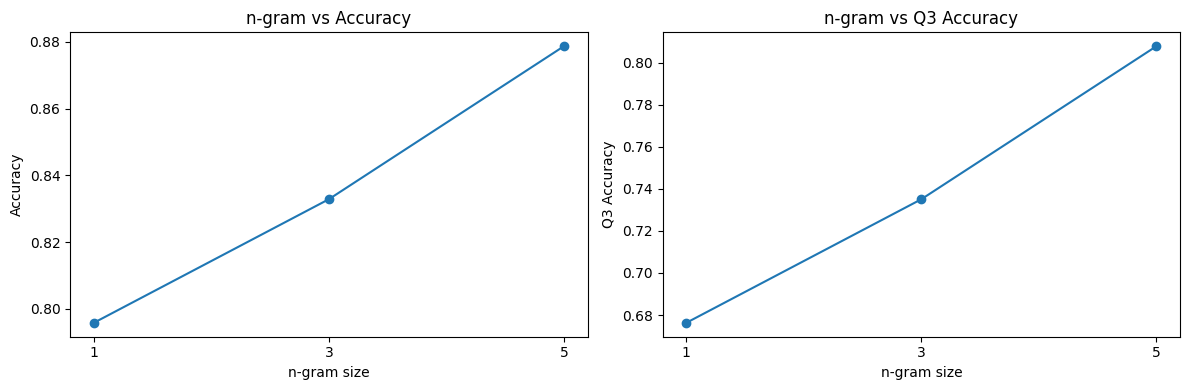

In [49]:
# Extract values
n_values = sorted(results.keys())
accuracies = [results[n]["accuracy"] for n in n_values]
q3_scores = [results[n]["q3_acc"] for n in n_values]


fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
# Plot accuracy
ax[0].plot(n_values, accuracies, marker='o')
ax[0].set_title("n-gram vs Accuracy")
ax[0].set_xlabel("n-gram size")
ax[0].set_ylabel("Accuracy")
ax[0].set_xticks(n_values)
# Plot Q3 Accuracy
ax[1].plot(n_values, q3_scores, marker='o')
ax[1].set_title("n-gram vs Q3 Accuracy")
ax[1].set_xlabel("n-gram size")
ax[1].set_ylabel("Q3 Accuracy")
ax[1].set_xticks(n_values)


plt.tight_layout()

plt.show()

In [66]:
#application of model with n-grams=5
def predict_structure(seq, model, tokenizer_encoder, tokenizer_decoder, maxlen_seq=128, n=5):
    # 1. Convert sequence → n-grams
    grams = [seq[i:i+n] for i in range(len(seq))]
    
    # 3. Tokenize
    seq_encoded = tokenizer_encoder.texts_to_sequences([grams])
    
    # 4. Pad
    seq_padded = sequence.pad_sequences(seq_encoded, maxlen=maxlen_seq, padding='post')
    
    # 5. Predict
    pred = model.predict(seq_padded)[0]
    
    # 6. Decode
    rev_decoder_index = {v: k for k, v in tokenizer_decoder.word_index.items()}
    
    pred_seq = ''
    for p in pred:
        i = np.argmax(p)
        if i != 0:
            pred_seq += rev_decoder_index[i]
        else:
            break
    
    return pred_seq

In [67]:
#example for application
test_seq = "MGDKPIWEQIGSSFINHYYQLFDNDRTQLGAIYIDASCLTWEGQQFQG"
test_seq = test_seq.lower()

predicted = predict_structure(
    test_seq,
    model,
    tokenizer_encoder,
    tokenizer_decoder,
    maxlen_seq=128,
    n=5   # IMPORTANT: must match training
)
print('protein sequence:', test_seq.upper())
print('secondary structure:', predicted.upper())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
protein sequence: MGDKPIWEQIGSSFINHYYQLFDNDRTQLGAIYIDASCLTWEGQQFQG
secondary structure: CCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHEEEEEEEEEECCEEC


#

**Discussion**

Protein secondary structure can be calculated based on its atoms' 3D coordinates once the protein's 3D structure is solved using X-ray crystallography or NMR. Commonly, DSSP is the tool used for calculating the secondary structure and assigns one of the following secondary structure types (https://swift.cmbi.umcn.nl/gv/dssp/index.html) to every amino acid in a protein:

C: Loops and irregular elements (corresponding to the blank characters output by DSSP)
E: β-strand
H: α-helix
B: β-bridge
G: 3-helix
I: π-helix
T: Turn
S: Bend
However, X-ray or NMR is expensive. Ideally, we would like to predict the secondary structure of a protein based on its primary sequence directly, which has had a long history. A review on this topic is published recently, Sixty-five years of the long march in protein secondary structure prediction: the final stretch?.

For the purpose of secondary structure prediction, it is common to simplify the aforementioned eight states (Q8) into three (Q3) by merging (E, B) into E, (H, G, I) into E, and (C, S, T) into C. The current accuracy for three-state (Q3) secondary structure prediction is about ~85% while that for eight-state (Q8) prediction is <70%. The exact number depends on the particular test dataset used.

**Dataset**
The main dataset lists peptide sequences and their corresponding secondary structures. It is a transformation of https://cdn.rcsb.org/etl/kabschSander/ss.txt.gz downloaded at 2018-06-06 from RSCB PDB into a tabular structure.

**Description of columns:**

pdb_id: the id used to locate its entry on https://www.rcsb.org/
chain_code: when a protein consists of multiple peptides (chains), the chain code is needed to locate a particular one.
seq: the sequence of the peptide
sst8: the eight-state (Q8) secondary structure
sst3: the three-state (Q3) secondary structure
len: the length of the peptide
has_nonstd_aa: whether the peptide contains nonstandard amino acids (B, O, U, X, or Z).
Key steps in the transformation:

Both Q3 and Q8 secondary structure sequences are listed.
All nonstandard amino acids, which includes B, O, U, X, and Z, (see here for their meanings) are masked with "*" character.
An additional column (has_nonstd_aa) is added to indicate whether the protein sequence contains nonstandard amino acids.
A subset of the sequences with low sequence identity and high resolution, ready for training, is also provided
For details of curation, please see https://github.com/zyxue/pdb-secondary-structure.

A subset (9079 sequences) based on sequences culled by PISCES with more strict quality control is also provided. This dataset is considered ready for training models.

The culled subset generated on 2018-05-31 with cutoffs of 25%, 2Å, and 0.25 for sequence identity, resolution and R-factor respectively, is used. The URL to the original culled list is http://dunbrack.fccc.edu/Guoli/culledpdb_hh/cullpdb_pc25_res2.0_R0.25_d180531_chains9099.gz, but it may not be permanently available. This dataset contains more columns from cullpdb_pc25_res2.0_R0.25_d180531_chains9099.gz with self-explanatory names.

For more about PISCES, please see https://academic.oup.com/bioinformatics/article/19/12/1589/258419.

**Processing**:
We are selecting only “clean” protein sequences and keep sequences with length ≤ 128. We also remove sequences with non-standard amino acids. We convert each sequence into substrings of length n(n=3). We use n-gram here for better prediction. The tokenizer builds a dictionary of your n-grams. After that by applying texts_to_sequences methode we replace each n-gram with its assigned number. Padding is here important because Neural networks need same-length input (128), but sequences have different lengths. padding='post' adds zeros at the end. After that we work on the target side. We want to convert the secondary structure labels into a format the model can learn from. Here we convert each character to one label and bild a dictionary. And then we convert them to corresponding numbers in the dictionary. Next step is the padding. At the end each number becomes a vector. We have 4 classes (including 0).
Total number of unique input tokens (n-grams) including padding(0) is 8421 and total number of output classes icluding padding(0) is 4. After that i bilt the model including Input, Embedding and BiLSTM for prediction. 

we have now 128 positions (sequence length) and each position has 128 features (from BiLSTM). TimeDistributed layer applies the same Dense layer to each position in the sequence. Dense layer converts each position’s features to probabilities over classes. Highest value is corresponded to predicted class. TimeDistributed dense predicts structure for each position. Then we create a mask to ignore padding and avoid inflating the accuracy. The model was trained for 5 epochs. Each epoch tries to improve the model weights so predictions get closer to the true secondary structure. q3_acc(Q3 accuracy which ignores padding) is always lower than accuracy ,because padding inflates the normal accuracy. Validation q3_acc (~82%) is close to training. That means that there is no severe overfitting. Training loss decreases with repeating training. That is an indicator for effective learning. This model works generally good but there are some mistakes. This model prefers predicting C. Wenn n-gram increases, this leads to the increase of accuracy and Q3 accuracy of model.

